In [11]:
!unzip test_set.zip

Archive:  test_set.zip
replace test_set/cats/_DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [12]:
!unzip training_set.zip

Streaming output truncated to the last 5000 lines.
  inflating: training_set/cats/cat.3705.jpg  
  inflating: training_set/cats/cat.3706.jpg  
  inflating: training_set/cats/cat.3707.jpg  
  inflating: training_set/cats/cat.3708.jpg  
  inflating: training_set/cats/cat.3709.jpg  
  inflating: training_set/cats/cat.371.jpg  
  inflating: training_set/cats/cat.3710.jpg  
  inflating: training_set/cats/cat.3711.jpg  
  inflating: training_set/cats/cat.3712.jpg  
  inflating: training_set/cats/cat.3713.jpg  
  inflating: training_set/cats/cat.3714.jpg  
  inflating: training_set/cats/cat.3715.jpg  
  inflating: training_set/cats/cat.3716.jpg  
  inflating: training_set/cats/cat.3717.jpg  
  inflating: training_set/cats/cat.3718.jpg  
  inflating: training_set/cats/cat.3719.jpg  
  inflating: training_set/cats/cat.372.jpg  
  inflating: training_set/cats/cat.3720.jpg  
  inflating: training_set/cats/cat.3721.jpg  
  inflating: training_set/cats/cat.3722.jpg  
  inflating: training_set/cats/

In [25]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Input,Flatten,BatchNormalization,Dropout

In [14]:
#generators
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/training_set',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256),
)

Found 8005 files belonging to 2 classes.


In [15]:
validation_ds=keras.utils.image_dataset_from_directory(
    directory='/content/test_set',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256),
)

Found 2023 files belonging to 2 classes.


In [16]:
#Normalize
def process(image,label):
  image=tf.cast(image/255.,tf.float32)
  return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [26]:
#create CNN model
model=Sequential()
model = Sequential([
    Input(shape=(256, 256, 3)),

    Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'),

    Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'),

    Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])


In [27]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [28]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [29]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.5570 - loss: 3.0202 - val_accuracy: 0.5146 - val_loss: 1.8213
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.5724 - loss: 0.6816 - val_accuracy: 0.5324 - val_loss: 0.6809
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.5959 - loss: 0.6631 - val_accuracy: 0.5645 - val_loss: 0.6724
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.6162 - loss: 0.6577 - val_accuracy: 0.5146 - val_loss: 2.5103
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.6420 - loss: 0.6367 - val_accuracy: 0.6031 - val_loss: 0.6439
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.6671 - loss: 0.5887 - val_accuracy: 0.6555 - val_loss: 0.8859
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.7053 - loss: 0.5289 - val_accuracy: 0.7118 - val_loss: 0.6116
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.7431 - loss: 0.4836 

In [22]:
import matplotlib.pyplot as plt

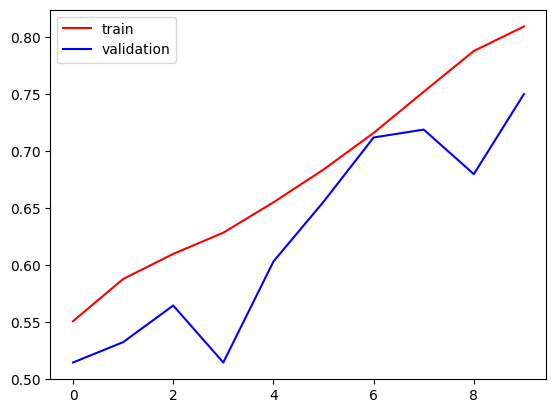

In [30]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

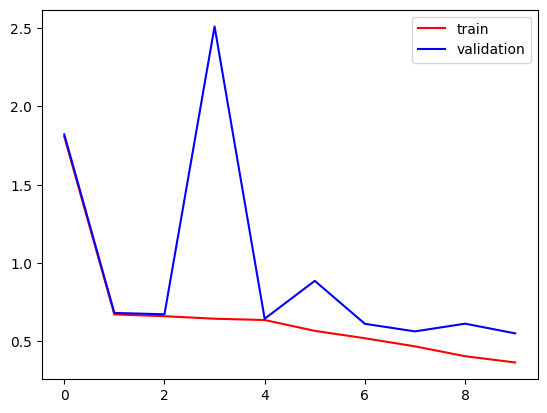

In [31]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()